In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/processed/civilisations_clean.csv")

# Build directed graph
G = nx.DiGraph()

# Add all civilisations as nodes
for _, row in df.iterrows():
    G.add_node(
        row['name'],
        region=row['region'],
        founded=row['founded_year'],
        collapsed=row['collapse_end_year'],
        lifespan=row['lifespan_years'],
        trigger=row['primary_collapse_trigger'],
        peak_pop=row['peak_population_m'],
        peak_territory=row['peak_territory_km2']
    )

# Add directed edges from interaction fields
edge_records = []

for _, row in df.iterrows():
    source = row['name']

    # Edge type 1: CONQUERED_BY (A was conquered by B → B→A edge)
    if pd.notna(row['conquered_by']) and row['conquered_by']:
        targets = [t.strip() for t in str(row['conquered_by']).split('|')]
        for target in targets:
            # Find closest match in our dataset
            matches = [n for n in G.nodes() if target.lower() in n.lower()
                      or n.lower() in target.lower()]
            if matches:
                G.add_edge(matches[0], source,
                          edge_type='conquest',
                          weight=3)
                edge_records.append({
                    'source': matches[0], 'target': source,
                    'edge_type': 'conquest', 'weight': 3
                })

    # Edge type 2: PRESSURED_BY (A was pressured by B → B→A edge)
    if pd.notna(row['pressured_by']) and row['pressured_by']:
        targets = [t.strip() for t in str(row['pressured_by']).split('|')]
        for target in targets:
            matches = [n for n in G.nodes() if target.lower() in n.lower()
                      or n.lower() in target.lower()]
            if matches:
                G.add_edge(matches[0], source,
                          edge_type='pressure',
                          weight=2)
                edge_records.append({
                    'source': matches[0], 'target': source,
                    'edge_type': 'pressure', 'weight': 2
                })

    # Edge type 3: SUCCEEDED_BY (A succeeded by B → A→B edge)
    if pd.notna(row['succeeded_by']) and row['succeeded_by']:
        targets = [t.strip() for t in str(row['succeeded_by']).split('|')]
        for target in targets:
            matches = [n for n in G.nodes() if target.lower() in n.lower()
                      or n.lower() in target.lower()]
            if matches:
                G.add_edge(source, matches[0],
                          edge_type='succession',
                          weight=1)
                edge_records.append({
                    'source': source, 'target': matches[0],
                    'edge_type': 'succession', 'weight': 1
                })

edges_df = pd.DataFrame(edge_records)

print("=== NETWORK BUILT ===")
print(f"Nodes (civilisations): {G.number_of_nodes()}")
print(f"Edges (interactions):  {G.number_of_edges()}")
print(f"\nEdge type breakdown:")
print(edges_df['edge_type'].value_counts())
print(f"\nNetwork density: {nx.density(G):.4f}")
print(f"Is weakly connected: {nx.is_weakly_connected(G)}")

=== NETWORK BUILT ===
Nodes (civilisations): 112
Edges (interactions):  187

Edge type breakdown:
edge_type
pressure      106
succession     81
conquest       54
Name: count, dtype: int64

Network density: 0.0150
Is weakly connected: False


In [2]:
print("=" * 60)
print("NETWORK CENTRALITY ANALYSIS")
print("=" * 60)

# In-degree: how many empires targeted/pressured/succeeded this one
in_degree = dict(G.in_degree())
# Out-degree: how many empires this one targeted/pressured/spawned
out_degree = dict(G.out_degree())

# PageRank: overall network influence
pagerank = nx.pagerank(G, weight='weight')

# Betweenness centrality: which nodes sit on most paths
# (bridges between different parts of history)
betweenness = nx.betweenness_centrality(G, weight='weight')

centrality_df = pd.DataFrame({
    'name': list(G.nodes()),
    'in_degree': [in_degree[n] for n in G.nodes()],
    'out_degree': [out_degree[n] for n in G.nodes()],
    'pagerank': [pagerank[n] for n in G.nodes()],
    'betweenness': [betweenness[n] for n in G.nodes()],
    'region': [G.nodes[n]['region'] for n in G.nodes()],
    'trigger': [G.nodes[n]['trigger'] for n in G.nodes()],
    'lifespan': [G.nodes[n]['lifespan'] for n in G.nodes()]
}).sort_values('pagerank', ascending=False)

print(f"\n── Top 10 by PageRank (most network-influential) ──")
print(centrality_df[['name','pagerank','in_degree',
                      'out_degree','region']].head(10).to_string(index=False))

print(f"\n── Top 10 by In-degree (most targeted/pressured) ──")
print(centrality_df.nlargest(10, 'in_degree')[
    ['name','in_degree','trigger','lifespan']].to_string(index=False))

print(f"\n── Top 10 by Out-degree (most predatory/influential) ──")
print(centrality_df.nlargest(10, 'out_degree')[
    ['name','out_degree','trigger','region']].to_string(index=False))

print(f"\n── Top 10 by Betweenness (historical bridges) ──")
print(centrality_df.nlargest(10, 'betweenness')[
    ['name','betweenness','region','lifespan']].to_string(index=False))

centrality_df.to_csv("../data/processed/network_centrality.csv", index=False)
print(f"\nCentrality scores saved: network_centrality.csv")

NETWORK CENTRALITY ANALYSIS

── Top 10 by PageRank (most network-influential) ──
                  name  pagerank  in_degree  out_degree      region
       Empire of Japan  0.030181          5           2   East Asia
                Goryeo  0.028902          4           1   East Asia
        Spanish Empire  0.028586          5           3      Europe
         Kushan Empire  0.027416          2           1  South Asia
          Roman Empire  0.026995          6           7      Europe
          Gupta Empire  0.026703          2           1  South Asia
                 Silla  0.026411          1           2   East Asia
           Inca Empire  0.022211          2           2    Americas
       Seleucid Empire  0.021570          4           2 Middle East
French Colonial Empire  0.020624          3           3      Europe

── Top 10 by In-degree (most targeted/pressured) ──
                   name  in_degree       trigger  lifespan
           Roman Empire          6 overextension       503


In [3]:
print("=" * 60)
print("COLLAPSE CHAIN ANALYSIS")
print("=" * 60)

# Find all simple paths of length >= 3 (meaningful chains)
# Only traverse conquest and succession edges for causal chains
conquest_succession = nx.DiGraph()
for u, v, data in G.edges(data=True):
    if data['edge_type'] in ['conquest', 'succession']:
        conquest_succession.add_edge(u, v, **data)

# Add nodes that might be missing
for node, data in G.nodes(data=True):
    if node not in conquest_succession:
        conquest_succession.add_node(node, **data)

# Find longest paths
all_chains = []
nodes = list(conquest_succession.nodes())

for source in nodes:
    for target in nodes:
        if source != target:
            try:
                paths = list(nx.all_simple_paths(
                    conquest_succession, source, target, cutoff=6
                ))
                for path in paths:
                    if len(path) >= 4:
                        all_chains.append(path)
            except nx.NetworkXError:
                continue

# Sort by length and deduplicate
all_chains.sort(key=len, reverse=True)
seen = set()
unique_chains = []
for chain in all_chains:
    key = tuple(chain)
    if key not in seen:
        seen.add(key)
        unique_chains.append(chain)

print(f"\nTotal chains of length ≥ 4 found: {len(unique_chains)}")
print(f"\n── Longest Causal Chains ──")

for i, chain in enumerate(unique_chains[:8]):
    # Get year span of chain
    start_year = G.nodes[chain[0]].get('founded', 0)
    end_year = G.nodes[chain[-1]].get('collapsed', 0)
    span = end_year - start_year

    print(f"\nChain {i+1} (length {len(chain)}, ~{abs(span)} years):")
    for j, node in enumerate(chain):
        year = G.nodes[node].get('collapsed', '?')
        region = G.nodes[node].get('region', '?')
        year_str = f"{abs(year)} BCE" if isinstance(year, (int,float)) and year < 0 else f"{year} CE"
        arrow = " → " if j < len(chain) - 1 else ""
        print(f"  {'  ' * j}{node} ({region}, collapsed {year_str}){arrow}")

COLLAPSE CHAIN ANALYSIS

Total chains of length ≥ 4 found: 166

── Longest Causal Chains ──

Chain 1 (length 7, ~1884 years):
  Neo-Babylonian Empire (Middle East, collapsed 539 BCE) → 
    Achaemenid Persian Empire (Middle East, collapsed 330 BCE) → 
      Seleucid Empire (Middle East, collapsed 63 BCE) → 
        Parthian Empire (Middle East, collapsed 224 CE) → 
          Sassanid Empire (Middle East, collapsed 651 CE) → 
            Umayyad Caliphate (Middle East, collapsed 750 CE) → 
              Abbasid Caliphate (Middle East, collapsed 1258 CE)

Chain 2 (length 7, ~1918 years):
  Achaemenid Persian Empire (Middle East, collapsed 330 BCE) → 
    Seleucid Empire (Middle East, collapsed 63 BCE) → 
      Parthian Empire (Middle East, collapsed 224 CE) → 
        Sassanid Empire (Middle East, collapsed 651 CE) → 
          Umayyad Caliphate (Middle East, collapsed 750 CE) → 
            Abbasid Caliphate (Middle East, collapsed 1258 CE) → 
              Mongol Empire (Central Asia, 

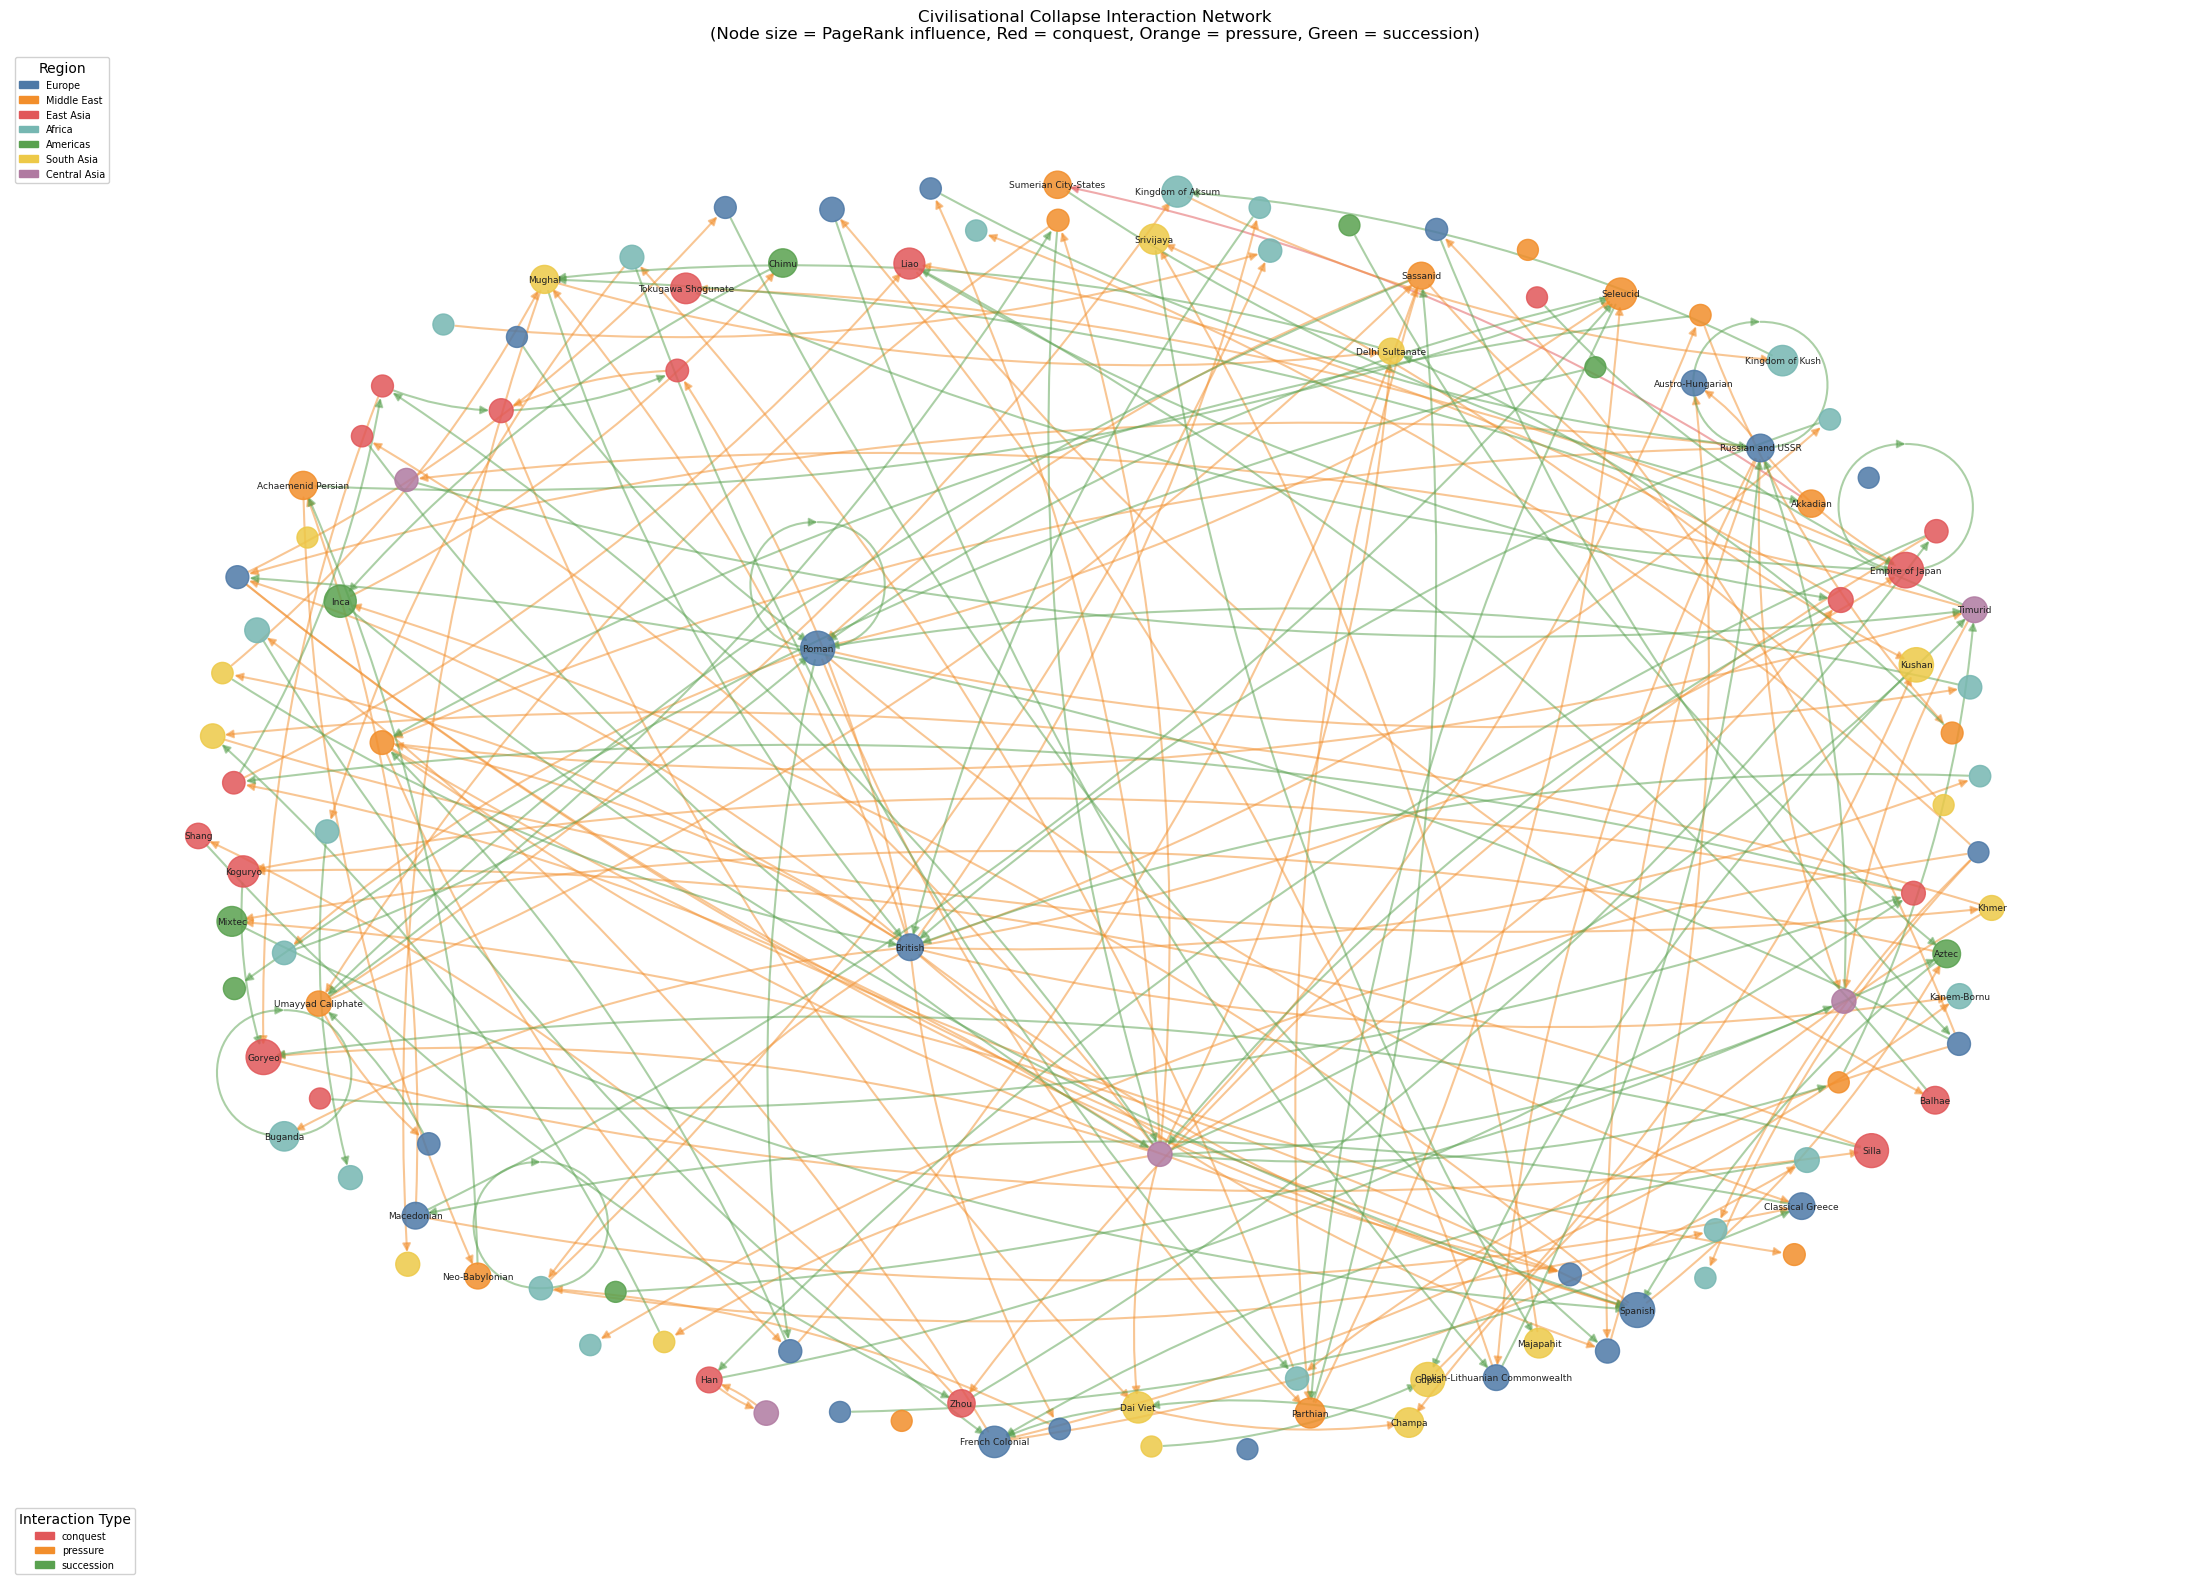

Saved: pillar4_network.png


In [4]:
REGION_COLOURS = {
    'Europe': '#4E79A7', 'Middle East': '#F28E2B',
    'East Asia': '#E15759', 'Africa': '#76B7B2',
    'Americas': '#59A14F', 'South Asia': '#EDC948',
    'Central Asia': '#B07AA1'
}

EDGE_COLOURS = {
    'conquest':   '#E15759',
    'pressure':   '#F28E2B',
    'succession': '#59A14F'
}

fig, ax = plt.subplots(figsize=(22, 16))

# Layout — use spring layout with weight
pos = nx.spring_layout(G, weight='weight', seed=42, k=2.5)

# Node sizes by pagerank
node_sizes = [pagerank[n] * 15000 + 200 for n in G.nodes()]
node_colours = [REGION_COLOURS.get(
    G.nodes[n]['region'], '#999999') for n in G.nodes()]

# Draw edges by type
for edge_type, colour in EDGE_COLOURS.items():
    edges = [(u, v) for u, v, d in G.edges(data=True)
             if d['edge_type'] == edge_type]
    if edges:
        nx.draw_networkx_edges(
            G, pos, edgelist=edges,
            edge_color=colour, alpha=0.5,
            width=1.5, arrows=True,
            arrowsize=12, ax=ax,
            connectionstyle='arc3,rad=0.1'
        )

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                       node_color=node_colours, alpha=0.85, ax=ax)

# Labels for high-pagerank nodes only
label_threshold = np.percentile(list(pagerank.values()), 60)
labels = {n: n.replace(' Empire', '').replace(' Dynasty', '')
          for n in G.nodes() if pagerank[n] >= label_threshold}
nx.draw_networkx_labels(G, pos, labels=labels,
                        font_size=6.5, font_color='#222222', ax=ax)

# Legends
region_patches = [mpatches.Patch(color=v, label=k)
                  for k, v in REGION_COLOURS.items()]
edge_patches = [mpatches.Patch(color=v, label=k)
                for k, v in EDGE_COLOURS.items()]

legend1 = ax.legend(handles=region_patches, title="Region",
                    loc='upper left', fontsize=7, framealpha=0.9)
ax.add_artist(legend1)
ax.legend(handles=edge_patches, title="Interaction Type",
          loc='lower left', fontsize=7, framealpha=0.9)

ax.set_title(
    "Civilisational Collapse Interaction Network\n"
    "(Node size = PageRank influence, "
    "Red = conquest, Orange = pressure, Green = succession)",
    fontsize=12, pad=10)
ax.axis('off')

plt.tight_layout()
plt.savefig("../data/processed/pillar4_network.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pillar4_network.png")

In [5]:
with open("../data/processed/pillar_1_2_results.json", "r") as f:
    results = json.load(f)

conquest_edges = len([e for e in G.edges(data=True)
                      if e[2]['edge_type'] == 'conquest'])
pressure_edges = len([e for e in G.edges(data=True)
                      if e[2]['edge_type'] == 'pressure'])
succession_edges = len([e for e in G.edges(data=True)
                        if e[2]['edge_type'] == 'succession'])

top_pagerank = centrality_df.nlargest(3, 'pagerank')['name'].tolist()
top_predators = centrality_df.nlargest(3, 'out_degree')['name'].tolist()
top_targets = centrality_df.nlargest(3, 'in_degree')['name'].tolist()
longest_chain_length = len(unique_chains[0]) if unique_chains else 0
longest_chain = unique_chains[0] if unique_chains else []

results.update({
    'pillar4_n_nodes': G.number_of_nodes(),
    'pillar4_n_edges': G.number_of_edges(),
    'pillar4_conquest_edges': conquest_edges,
    'pillar4_pressure_edges': pressure_edges,
    'pillar4_succession_edges': succession_edges,
    'pillar4_network_density': round(nx.density(G), 4),
    'pillar4_top_pagerank': top_pagerank,
    'pillar4_top_predators': top_predators,
    'pillar4_top_targets': top_targets,
    'pillar4_longest_chain_length': longest_chain_length,
    'pillar4_longest_chain': longest_chain
})

with open("../data/processed/pillar_1_2_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Pillar 4 results saved.")
print(f"\nNetwork summary:")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")
print(f"  Conquest edges:   {conquest_edges}")
print(f"  Pressure edges:   {pressure_edges}")
print(f"  Succession edges: {succession_edges}")
print(f"  Longest chain:    {longest_chain_length} civilisations")
print(f"  Chain: {' → '.join(longest_chain)}")

Pillar 4 results saved.

Network summary:
  Nodes: 112
  Edges: 187
  Conquest edges:   1
  Pressure edges:   106
  Succession edges: 80
  Longest chain:    7 civilisations
  Chain: Neo-Babylonian Empire → Achaemenid Persian Empire → Seleucid Empire → Parthian Empire → Sassanid Empire → Umayyad Caliphate → Abbasid Caliphate
